In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace
from IPython.display import clear_output

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, read_galaxy_fits, measure, plotting, analysis, multicat,
core, PipelineConfig, stack)
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from utils_lya_halo.measure import measure_all_bins, integrated_line_flux
from utils_lya_halo.stack import build_stacks

%matplotlib inline

LYA_REST = PipelineConfig.LYA_REST

# Reading in output and stacking

In [102]:
# ---------------------------------------------------------------- INPUTS
random_seed     = 10
bin_mode        = 'kpc'
bins            = [0, 10, 20, 30, 50, 80, 140, 300, 600, 1000, 2000]
field           = 'BOTH'

half_width      = 3.5            # +/- Angstrom around LYA_REST used as the "line" (Stage 3)
vr_approx       = 90             # rough |v| scale (km/s) -- not consumed in this cell;
                                # handy later e.g. plot_centroid_profile(..., ylims=(-3*vr_approx, 3*vr_approx))
stack_method    = 'biweight'
mask_method     = "segmap"

id_col          = "ID"

bg_inner_arcsec = 55.0
bg_outer_arcsec = 65.0

rest_wave_min   = 1100
rest_wave_max   = 1700
spexlim         = (rest_wave_min, rest_wave_max)

n_bootstrap     = 1000
np.random.seed(random_seed)    # reproducibility for anything you resample by hand below

# ---------------------------------------------------------------- CONFIG (drives everything below)
cfg_prod = replace(cfg,
                   field=field,
                   bin_mode=bin_mode,
                   bins=bins,
                   mask_method=mask_method,
                   bg_inner_arcsec=bg_inner_arcsec,
                   bg_outer_arcsec=bg_outer_arcsec,
                   rest_wave_min=rest_wave_min,
                   rest_wave_max=rest_wave_max,
                   n_bootstrap=n_bootstrap,
                   #flux_unit='flux_arcsec2',
                   #rest_density=False,
                   line_window=[LYA_REST - half_width, LYA_REST + half_width])

# ---------------------------------------------------------------- FILE PATHS
# one dict keyed by bin_mode -- add a new bin_mode by adding a key, no new elif
PRODUCT_PATHS = {
    'virial': {
        'AEGIS':  './outputs/galaxy_catc1488c_b8_8c91de_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits',
        'COSMOS': './outputs/galaxy_catc1488c_b8_8c91de_COSMOS_MOSDEF_virial_biweight_image_bg57-63.fits',
    },
    'kpc': {
        'AEGIS':  './outputs/galaxy_cat65a007_b10_ec8c16_AEGIS_MOSDEF_kpc_biweight_segmap_bg55-65.fits',
        'COSMOS': './outputs/galaxy_cat65a007_b10_ec8c16_COSMOS_MOSDEF_kpc_biweight_segmap_bg55-65.fits',
    },
}
try:
    paths = PRODUCT_PATHS[bin_mode.lower()]
except KeyError:
    raise ValueError(f"No file paths registered for bin_mode={bin_mode!r} "
                     f"(have: {list(PRODUCT_PATHS)}); add it to PRODUCT_PATHS.")

# ---------------------------------------------------------------- LOAD + CUT (per field)
products = {
    label: apply_finite_cut(read_galaxy_fits(path),
                            cfg_prod.cut_radial_bin, cfg_prod.min_good_wave)
    for label, path in paths.items()
}
product1, product2 = products['AEGIS'], products['COSMOS']   # kept for compatibility with older cells

# ---------------------------------------------------------------- (BOTH) COMBINE + STACK
mega = multicat.combine_products(products, label_col="SUBSET")

# ---------------------------------------------------------------- (SINGLE) COMBINE + STACK
stacks_by_field = multicat.stack_each(cfg_prod, products, keep_cube=True)   # {'AEGIS':stacks,'COSMOS':stacks}
stacks = stack.build_stacks(cfg_prod, mega, keep_cube=True)

print(f"BOTH:   {mega.ngal} galaxies")
print(f"AEGIS:  {products['AEGIS'].ngal} galaxies")
print(f"COSMOS: {products['COSMOS'].ngal} galaxies")

Finite-spectrum cut (bin 9, > 100 px): kept 227 / 244 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 275 / 278 galaxies
combined 2 products -> 502 galaxies (origin in column 'SUBSET')


BOTH:   502 galaxies
AEGIS:  227 galaxies
COSMOS: 275 galaxies


# Measuring

In [32]:
cfg_raw = replace(cfg_prod, flux_unit="raw")
stacks_raw = run_stack(cfg_raw, verbose=False)
clear_output()

wave  = stacks_raw["rest_wave"]
raw_flux = stacks_raw["stacks"]["biweight"]["flux"]
bounds = tuple(cfg_raw.line_window)
flux_curve = []
for r in range(raw_flux.shape[0]):
    res = integrated_line_flux(wave, raw_flux[r], bounds=bounds)
    flux_curve.append(res["flux_integral"])
    print(r, res["flux_integral"])

0 5.885584336477365e-19
1 4.721604155437034e-19
2 2.346317734898818e-19
3 1.0942349284650686e-19
4 2.641547299537032e-20
5 1.2625907584797596e-20
6 9.311710638591525e-21
7 6.238522832680507e-21
8 4.516537492754008e-21
9 2.082559338735035e-21


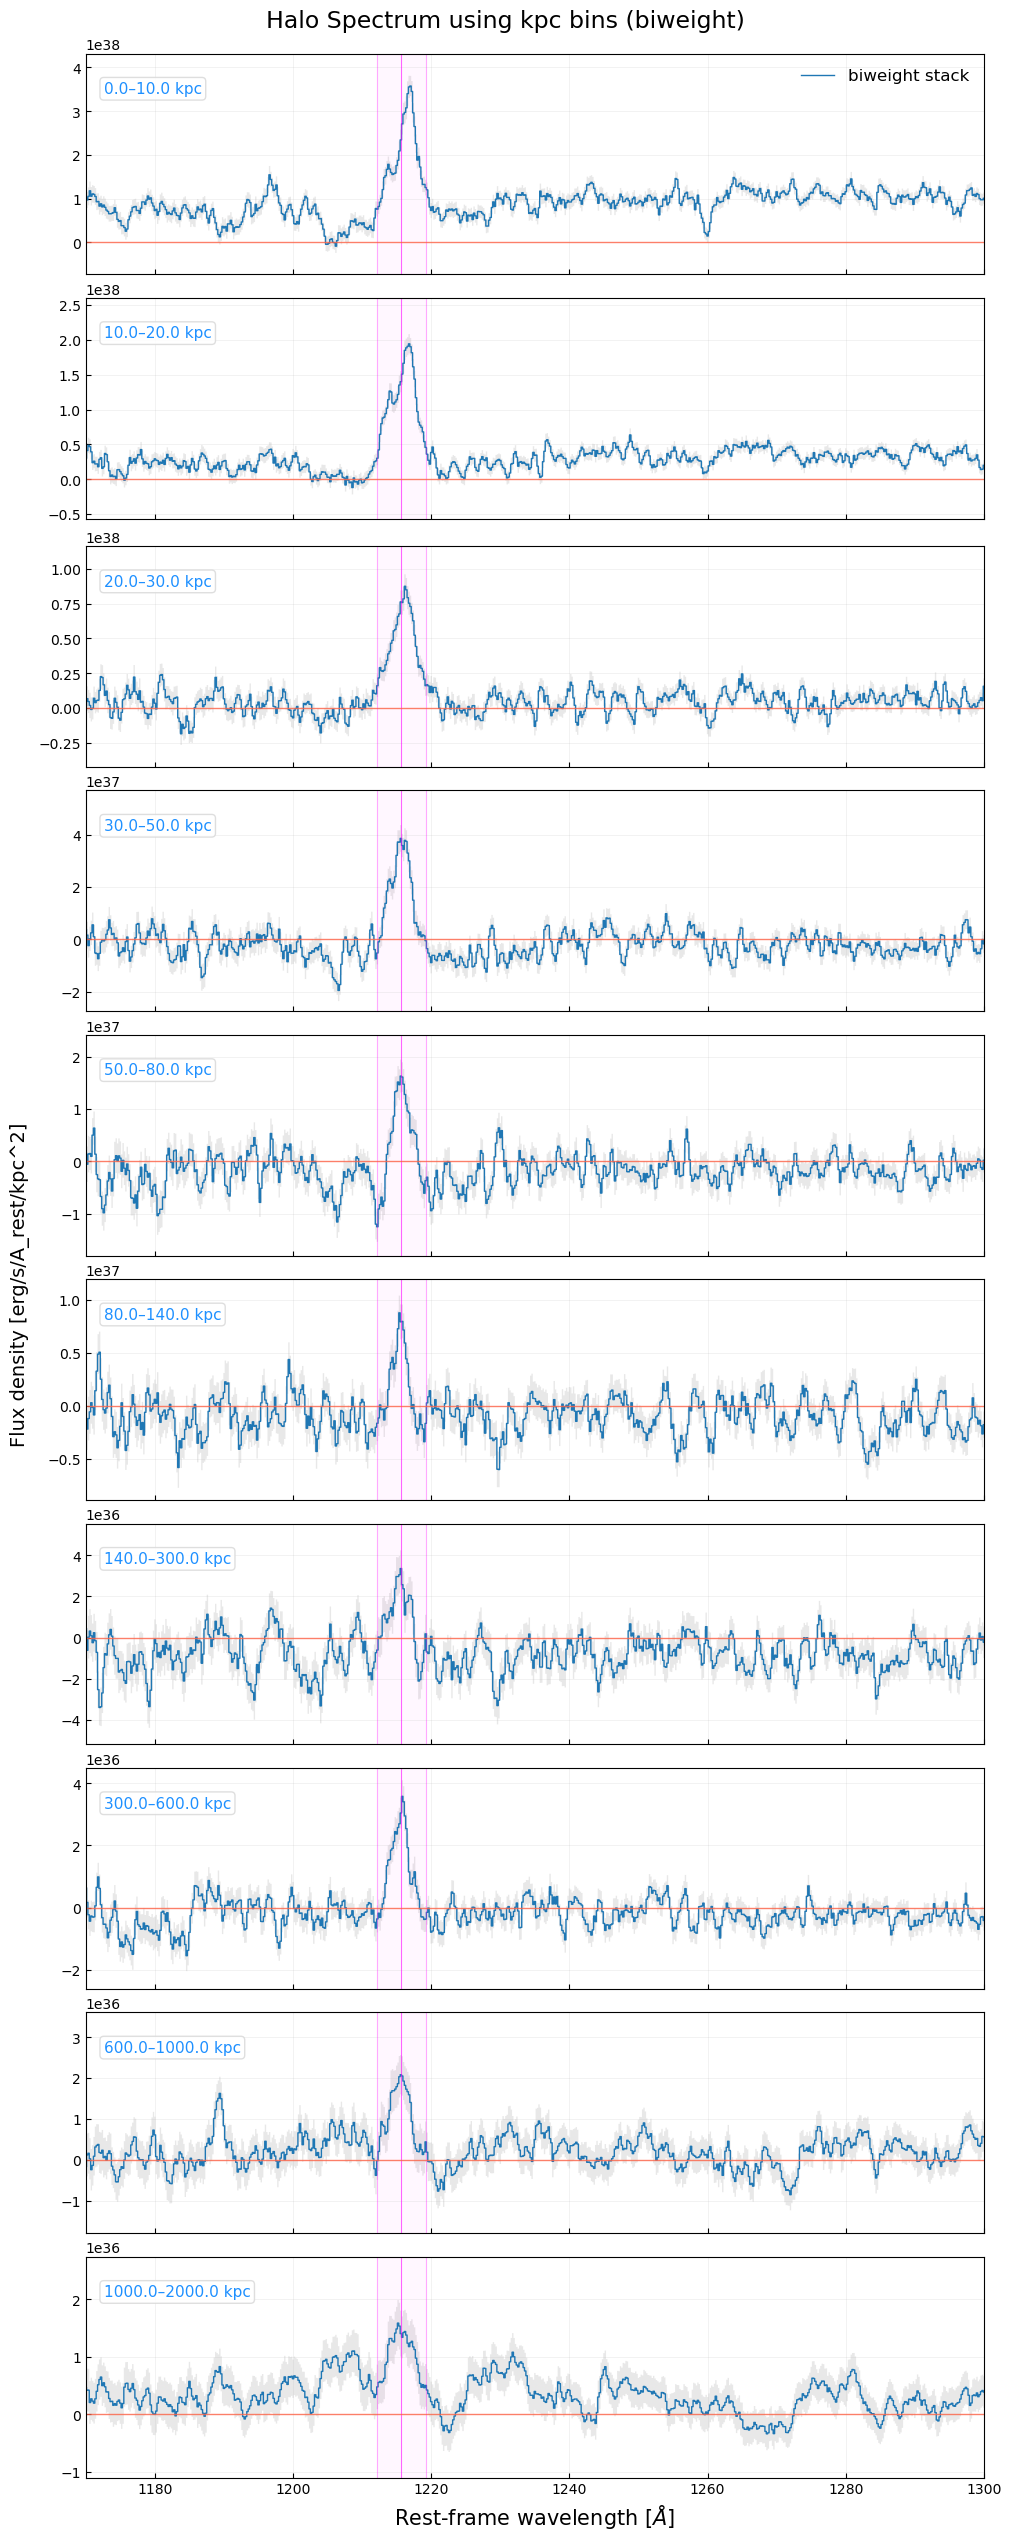

(<Figure size 1000x2500 with 10 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='Rest-frame wavelength [$\\AA$]'>], dtype=object))

In [33]:
plotting.plot_stack_panels(stacks,
    method="biweight",
    distance_type=bin_mode,
    title=None,
    xlim=(1170, 1300),
    lya_window=half_width,
    figsize_width=10,
    panel_height=2.5,
    show_err=True,
    smooth=None,
    savepath=None,
    dpi=300)

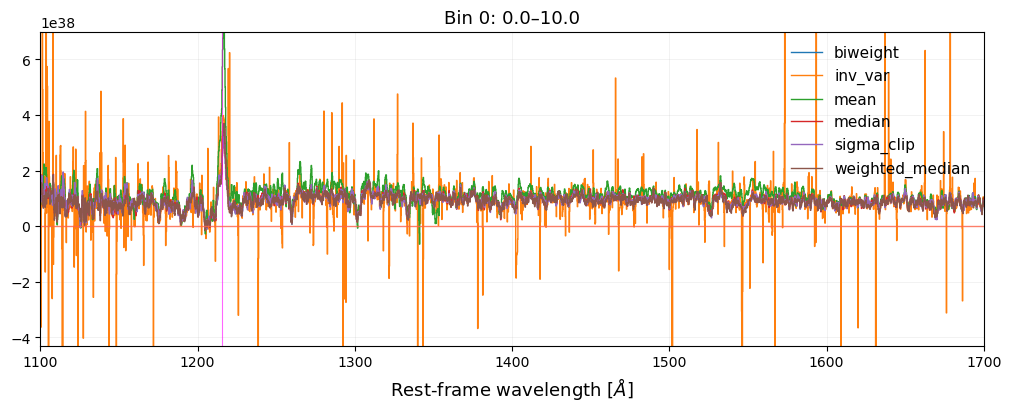

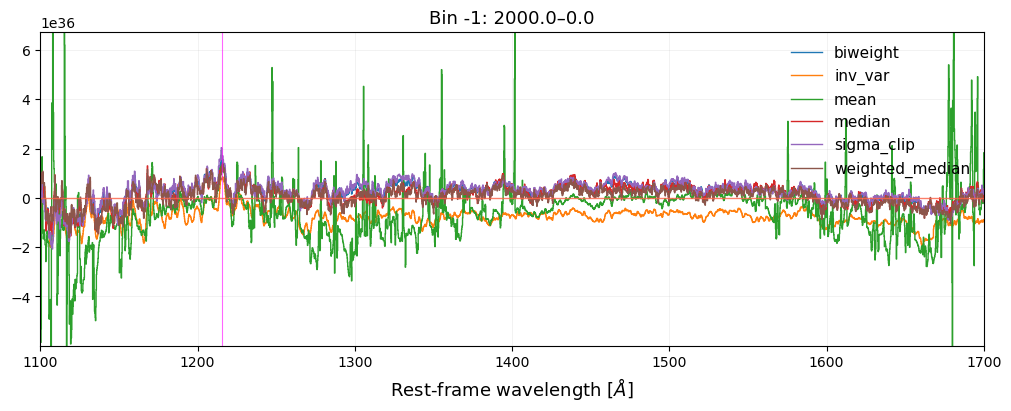

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Bin -1: 2000.0–0.0'}, xlabel='Rest-frame wavelength [$\\AA$]'>)

In [35]:
plotting.plot_methods_overlay(stacks,
    methods=None,
    radial_index=0,
    xlim=spexlim,
    smooth=None,
    title=None,
    set_ylim=True,
    ylim_pad=0.25,
    ylim_percentiles=(1, 99),
    include_zero=False)

plotting.plot_methods_overlay(stacks,
    methods=None,
    radial_index=-1,
    xlim=spexlim,
    smooth=None,
    title=None,
    set_ylim=True,
    ylim_pad=0.25,
    ylim_percentiles=(1, 99),
    include_zero=False)

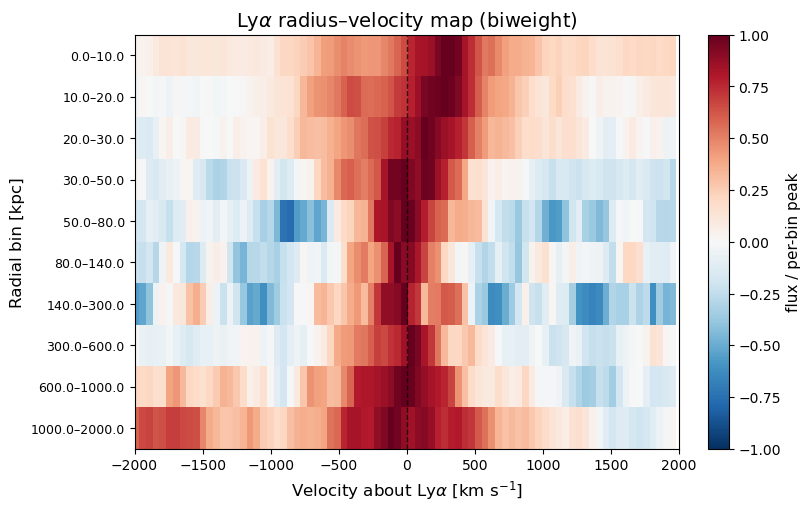

(<Figure size 800x500 with 2 Axes>,
 <Axes: title={'center': 'Ly$\\alpha$ radius–velocity map (biweight)'}, xlabel='Velocity about Ly$\\alpha$ [km s$^{-1}$]', ylabel='Radial bin [kpc]'>)

In [36]:
plotting.plot_radius_velocity_map(stacks,
    method="biweight",
    distance_type=bin_mode,
    vlim=(-2000, 2000),
    normalize="peak",
    cmap="RdBu_r",
    smooth=None,
    show_window=None,
    title=None,
    figsize=(8, 5),
    savepath=None,
    dpi=300)

# Bootstrap Pipeline

In [104]:
flux_rf = stacks['cube_flux']
err_rf  = stacks['cube_err']
wave    = stacks['rest_wave']

In [117]:
boot_b = measure.bootstrap_all(flux_rf, err_rf, wave,
    nboot=1000,
    bounds=cfg_prod.line_window,
    stack_method="biweight",
    compute_side_ratio=True,
    compute_stack_error=True,
    robust_stack_error=True,
    seed=1, verbose=True,
    weights=None,
    sigma_clip_sigma=3.0, sigma_clip_maxiters=5,
)

▶ bootstrap [flux_median]  |  nboot=1000  stack=biweight  centroid=flux_median  window=(1212.17,1219.17)  cont=median  side_ratio=True  stack_err=True  seed=1


bootstrap [flux_median]:   0%|          | 0/1000 [00:00<?, ?it/s]

In [118]:
boot_m = measure.bootstrap_all(flux_rf, err_rf, wave,
    nboot=1000,
    bounds=cfg_prod.line_window,
    stack_method="mean",
    compute_side_ratio=True,
    compute_stack_error=True,
    robust_stack_error=True,
    seed=1, verbose=True,
    weights=None,
    sigma_clip_sigma=3.0, sigma_clip_maxiters=5,
)

▶ bootstrap [flux_median]  |  nboot=1000  stack=mean  centroid=flux_median  window=(1212.17,1219.17)  cont=median  side_ratio=True  stack_err=True  seed=1


bootstrap [flux_median]:   0%|          | 0/1000 [00:00<?, ?it/s]

In [119]:
boot_s = measure.bootstrap_all(flux_rf, err_rf, wave,
    nboot=1000,
    bounds=cfg_prod.line_window,
    stack_method="sigma_clip",
    compute_side_ratio=True,
    compute_stack_error=True,
    robust_stack_error=True,
    seed=1, verbose=True,
    weights=None,
    sigma_clip_sigma=3.0, sigma_clip_maxiters=5,
)

▶ bootstrap [flux_median]  |  nboot=1000  stack=sigma_clip  centroid=flux_median  window=(1212.17,1219.17)  cont=median  side_ratio=True  stack_err=True  seed=1


bootstrap [flux_median]:   0%|          | 0/1000 [00:00<?, ?it/s]

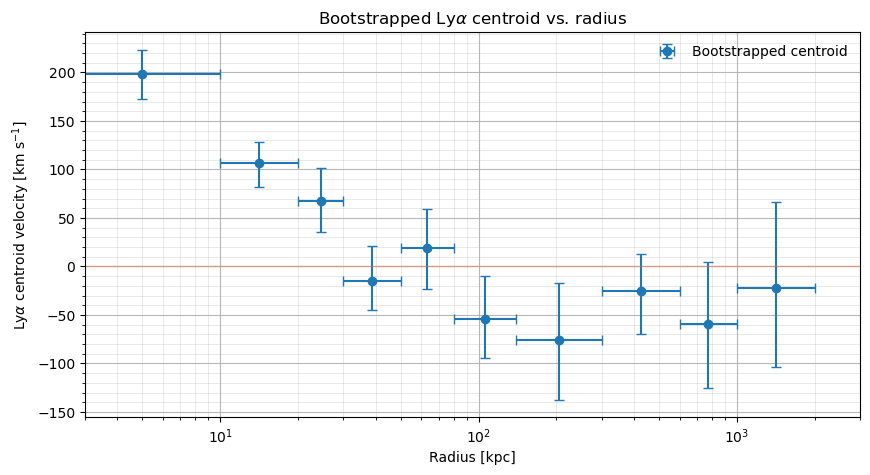

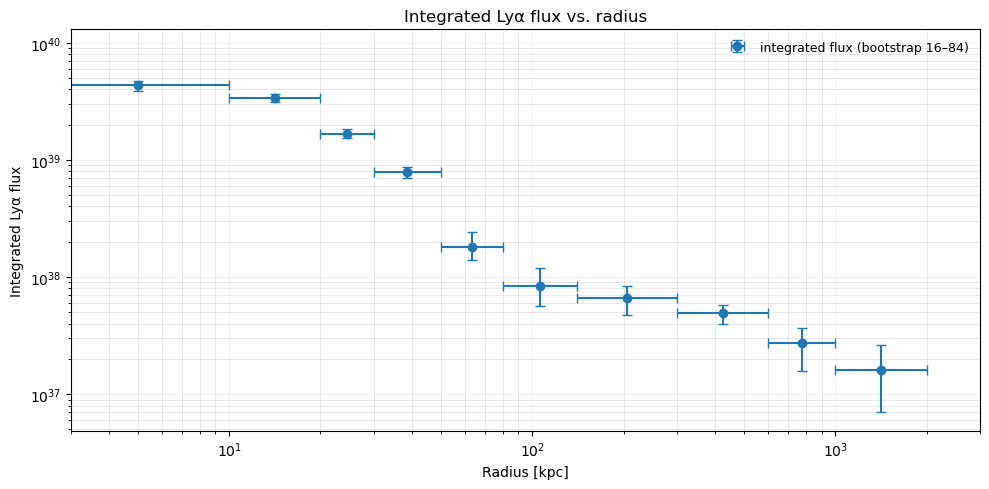

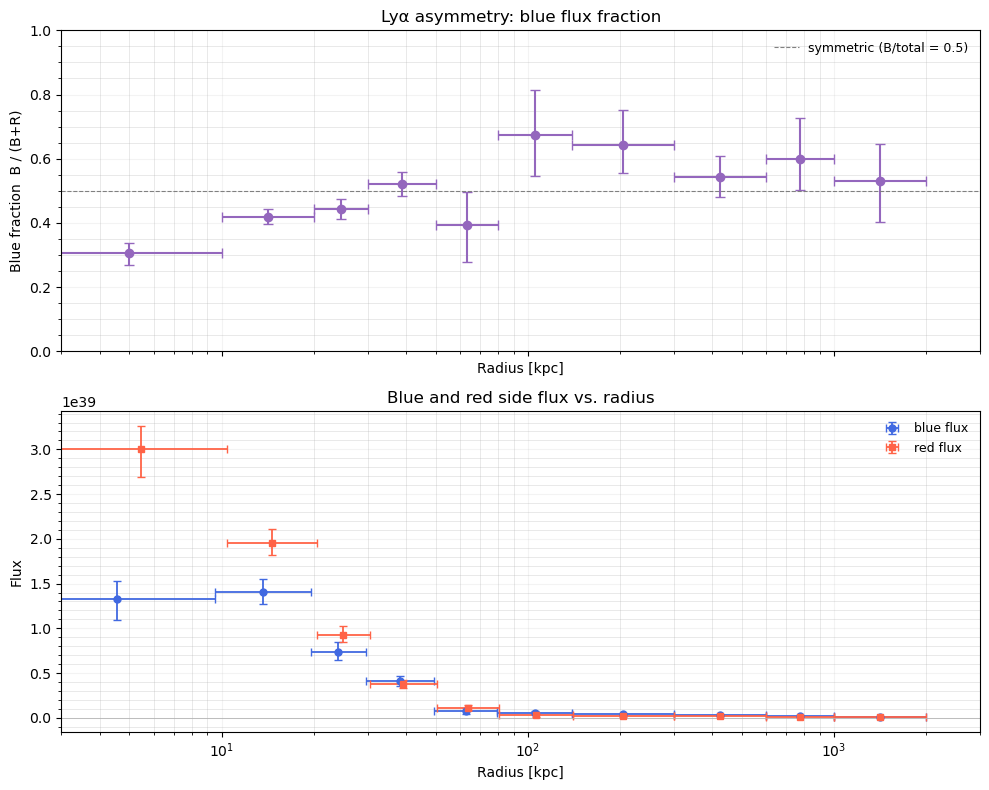

(<Figure size 1000x800 with 2 Axes>,
 (<Axes: title={'center': 'Lyα asymmetry: blue flux fraction'}, xlabel='Radius [kpc]', ylabel='Blue fraction  B / (B+R)'>,
  <Axes: title={'center': 'Blue and red side flux vs. radius'}, xlabel='Radius [kpc]', ylabel='Flux'>))

In [122]:
boot = boot_b

#xlims = (0.03, 30)
xlims = (3, 3000)

#Radial profiles
analysis.plot_centroid_profile(boot, stacks,
    ylims=None,
    xlims=xlims,
    figsize=(10, 5))
analysis.plot_flux_profile(boot, stacks,
    ylims=None,
    xlims=xlims,
    figsize=(10, 5))
analysis.plot_asymmetry_profile(boot, stacks,
    xlims=xlims,
    figsize=(10, 8))

In [41]:
analysis.compare_centroid_methods(stacks, config=cfg_prod)            # point-estimate table (config-driven continuum)

                  method |       0-10      10-20      20-30      30-50      50-80     80-140    140-300    300-600   600-1000  1000-2000
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 flux-weighted (clipped) |     +142.0      +48.6      +36.4      -22.4      +30.0      -70.1     -105.3      -35.6      -88.2       -0.8
 flux-weighted (no clip) |     +142.3      +48.6      +36.4      -21.9     +176.7     -145.9     -143.1      -37.9      -91.0       -8.1
Gaussian-weighted moment |     +218.0     +115.3      +80.2      -12.7      +13.8      -45.8      -80.2      -39.4      -53.6      -21.1
        Gaussian fit (µ) |     +129.7      +79.4      +59.5       -1.6      +34.2      -47.7      -92.1      -42.3      -48.4      -16.2
          50% cumulative |     +198.6     +104.7      +68.9      -12.9      +14.8      -51.4      -85.1      -25.1      -65.9      -17.1
          parabolic peak |     +310.4    

{'methods': ['fw_clip',
  'fw_noclip',
  'gauss_weighted',
  'gaussian',
  'flux_median',
  'peak'],
 'velocities': {'fw_clip': array([ 141.98267039,   48.63634699,   36.35933164,  -22.41177987,
           29.98435367,  -70.09564064, -105.32202098,  -35.60389846,
          -88.2323383 ,   -0.81941569]),
  'fw_noclip': array([ 142.3284287 ,   48.63634699,   36.35933164,  -21.94662249,
          176.71532659, -145.87966928, -143.11682115,  -37.91162142,
          -90.96097501,   -8.08998253]),
  'gauss_weighted': array([218.03160018, 115.28426012,  80.18360754, -12.73552902,
          13.82579652, -45.82391305, -80.21513674, -39.42338137,
         -53.59022105, -21.05226422]),
  'gaussian': array([129.72866166,  79.36771236,  59.45483316,  -1.63340414,
          34.16039133, -47.6983312 , -92.080887  , -42.25332728,
         -48.41541333, -16.15048387]),
  'flux_median': array([198.55129794, 104.71659965,  68.93553651, -12.94537819,
          14.79751982, -51.357826  , -85.13876865, -25.

In [42]:
cmp = analysis.measure_centroid_methods(
    stacks, config=cfg_prod, nboot=1000,
    methods=("fw_clip", "fw_noclip", "flux_median", "gaussian", "gauss_weighted"),
    bounds=cfg_prod.line_window, seed=random_seed)

▶ centroid [flux-weighted (clipped)]  |  nboot=1000  stack=biweight  centroid=flux_weighted  window=(1212.17,1219.17)  cont=median  side_ratio=False  stack_err=False  seed=10


centroid [flux-weighted (clipped)]:   0%|          | 0/1000 [00:00<?, ?it/s]

▶ centroid [flux-weighted (no clip)]  |  nboot=1000  stack=biweight  centroid=flux_weighted  window=(1212.17,1219.17)  cont=median  side_ratio=False  stack_err=False  seed=10


centroid [flux-weighted (no clip)]:   0%|          | 0/1000 [00:00<?, ?it/s]

▶ centroid [50% cumulative]  |  nboot=1000  stack=biweight  centroid=flux_median  window=(1212.17,1219.17)  cont=median  side_ratio=False  stack_err=False  seed=10


...

▶ centroid [Gaussian fit (µ)]  |  nboot=1000  stack=biweight  centroid=gaussian  window=(1212.17,1219.17)  cont=median  side_ratio=False  stack_err=False  seed=10


centroid [Gaussian fit (µ)]:   0%|          | 0/1000 [00:00<?, ?it/s]

▶ centroid [Gaussian-weighted moment]  |  nboot=1000  stack=biweight  centroid=gauss_weighted  window=(1212.17,1219.17)  cont=median  side_ratio=False  stack_err=False  seed=10


centroid [Gaussian-weighted moment]:   0%|          | 0/1000 [00:00<?, ?it/s]


                method |       0-10      10-20      20-30      30-50      50-80     80-140    140-300    300-600   600-1000  1000-2000
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
flux-weighted (clipped) |     +142.0      +48.6      +36.4      -22.4      +30.0      -70.1     -105.3      -35.6      -88.2       -0.8
flux-weighted (no clip) |     +142.3      +48.6      +36.4      -21.9     +176.7     -145.9     -143.1      -37.9      -91.0       -8.1
        50% cumulative |     +198.6     +104.7      +68.9      -12.9      +14.8      -51.4      -85.1      -25.1      -65.9      -17.1
      Gaussian fit (µ) |     +129.7      +79.4      +59.5       -1.6      +34.2      -47.7      -92.1      -42.3      -48.4      -16.2
Gaussian-weighted moment |     +218.0     +115.3      +80.2      -12.7      +13.8      -45.8      -80.2      -39.4      -53.6      -21.1

  units: km/s  (fiducial centroid; ±16/84 bars sh

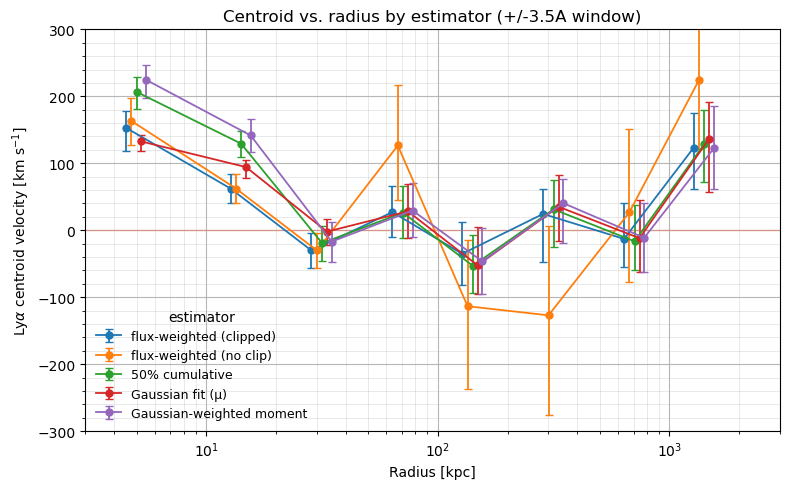

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Centroid vs. radius by estimator (+/-3.5A window)'}, xlabel='Radius [kpc]', ylabel='Ly$\\alpha$ centroid velocity [km s$^{-1}$]'>)

In [17]:
analysis.plot_centroid_methods(cmp, stacks,
    bin_mode='kpc',
    #vr_ticks=(0.1, 0.2, 0.5, 1, 2, 5, 10, 20),
    ylims=(-300, 300),
    xlims=xlims,
    jitter=0.05,
    figsize=(8, 5),
    title="Centroid vs. radius by estimator (+/-3.5A window)",
    save_fig=False)

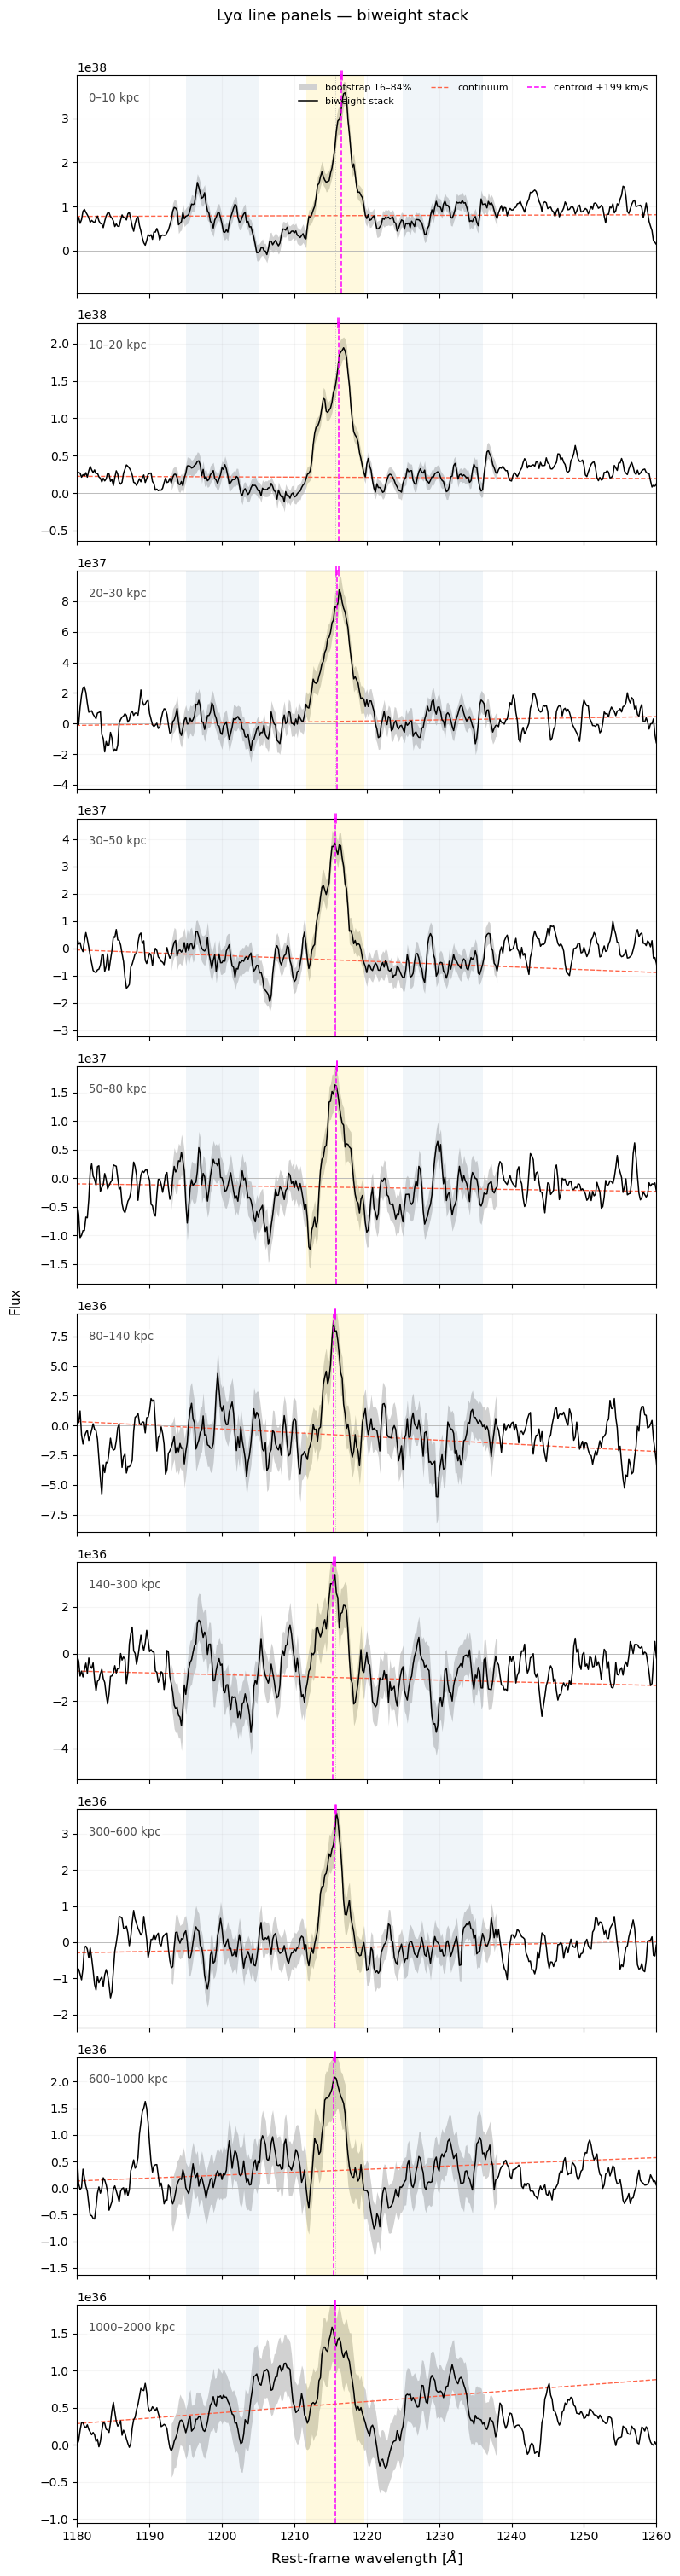

(<Figure size 800x3000 with 10 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='Rest-frame wavelength [$\\AA$]'>], dtype=object))

In [103]:
#Spectral diagnostics
analysis.plot_line_panels(stacks, boot_b,
    xlim=(1180, 1260),
    panel_height=3,
    figwidth=8)

In [21]:
conf = anaysis.measurement_confidence(boot_b, stacks)

       bin       v_fid±err    nσ≠0  flux S/N    ok%  notes
──────────────────────────────────────────────────────────
     0-0.1   +200.5± 27.6     7.3       9.4   100%  
   0.1-0.2   +172.6± 23.3     7.0      12.5   100%  
   0.2-0.5     -3.7± 28.7     0.1      13.3   100%  consistent w/ 0
     0.5-1     +9.8± 40.4     0.2       5.7   100%  consistent w/ 0
       1-2    -26.0± 42.9     0.6       3.2   100%  consistent w/ 0
       2-5    -16.9± 44.6     0.4       2.9   100%  faint, consistent w/ 0
      5-10    +49.2± 53.8     0.8       3.6   100%  consistent w/ 0
     10-20   +148.0± 69.1     2.1       3.1   100%  

  flux S/N = galaxy-bootstrap stability of integrated flux (not photon S/N).
  nσ≠0 is a gut-check only; use validation.py for real significance.

[7.27804464 7.04121517 0.11614226 0.23861441 0.61287632 0.36591027
 0.84882924 2.09691964]


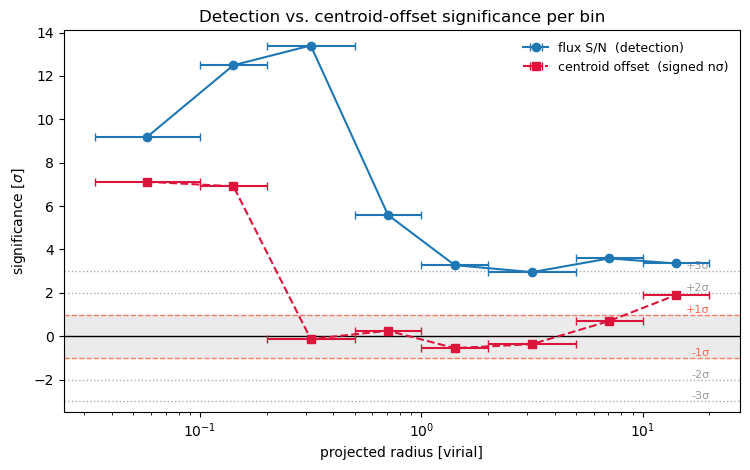

In [5]:
#Plots BOTH curves; centroid is signed from boot["centroid_v_fid"]
fig, ax = plotting.plot_significance_comparison(conf, boot)